# COMP662 Assignment 1 — Synthetic Dataset Generation


## Runtime environment

Run this notebook on Kaggle with the **T4 x2** accelerator enabled. The implementation records the detected device and wall-clock time; when two CUDA devices are present, the CVAE uses `DataParallel`. The random-forest classifier is intentionally CPU-based because scikit-learn does not use CUDA.


### Kaggle measured run (version 6)

The submitted Kaggle kernel completed successfully on **Tesla T4 x2**: [COMP662 A1 Kaggle verification](https://www.kaggle.com/code/yangliunz/comp662-a1-kaggle-verification). With seed 42 and 100 CVAE epochs, the end-to-end measured runtime was **148.153 seconds**. The baseline random forest achieved held-out macro-F1 **0.9322** and accuracy **0.9327**; the augmented model achieved macro-F1 **0.9263** and accuracy **0.9265**. Therefore the final saved model remains the baseline random forest.


In [1]:
# Import the existing assignment implementation and the small helpers used below.
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# Use paths relative to this notebook so it runs from notebooks/ or the repository root.
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import assignment1 as a1
DATA_PATH = a1.DATA
FIGURES = a1.FIGURES
MODELS = a1.MODELS
SEED = 42

a1.set_seed()
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)
print(f"Runtime benchmark: device={a1.runtime_device()}; seed={SEED}; data={DATA_PATH}")


## Task 1 — Data understanding and concise exploratory data analysis


### 1.1 Class distribution: counts and percentages


Classes 0 and 1 are the largest groups (26.8% and 26.2%), while class 4 is the smallest (13.4%). This is a moderate imbalance, so raw accuracy could hide poorer minority-class performance; later splits and CV are stratified and macro-F1 is primary.


,count,percentage
Class,,
0,3246,26.802081
1,3174,26.207580
2,2336,19.288250
3,1727,14.259764
4,1628,13.442325


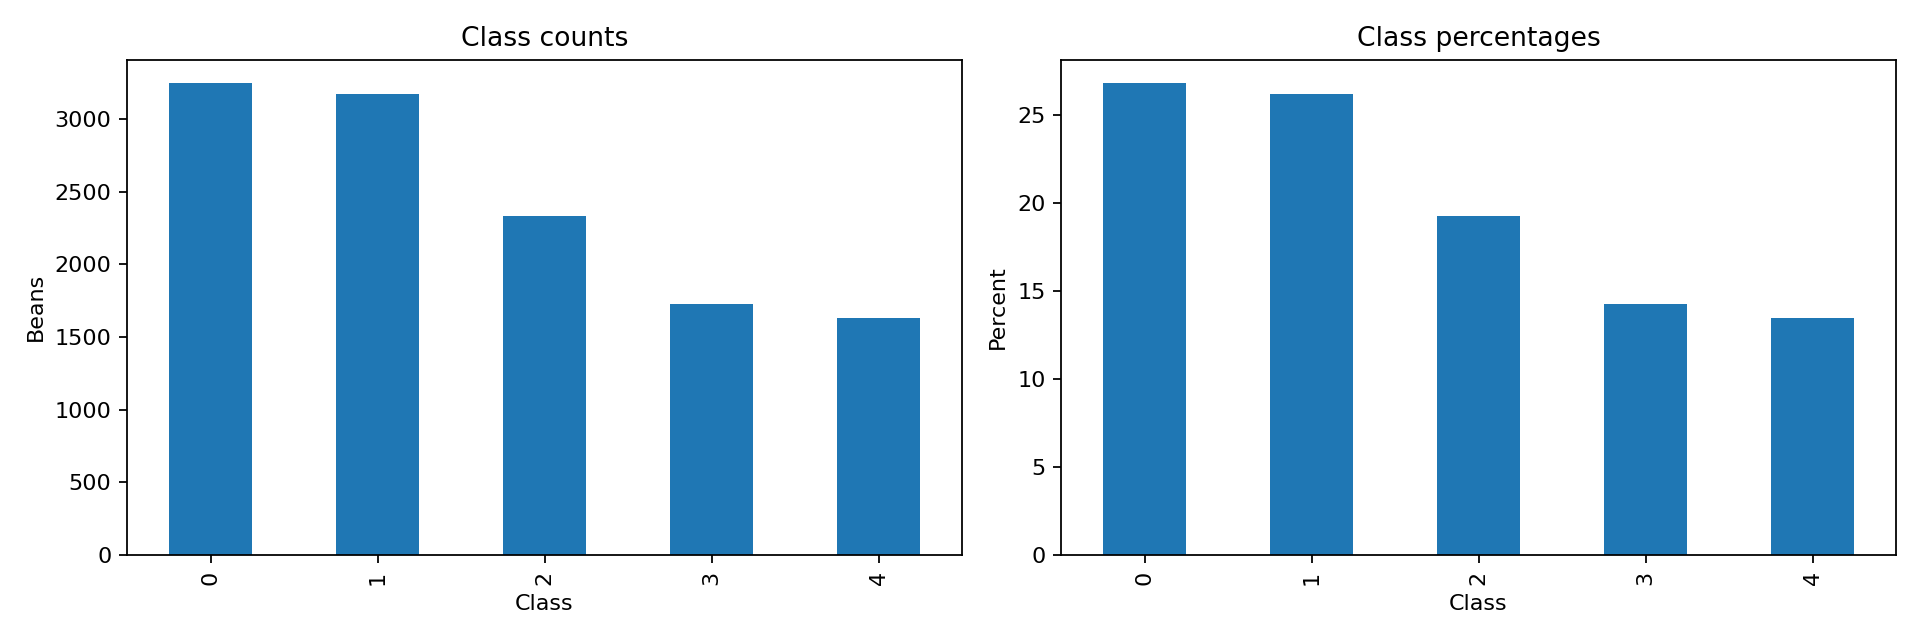

In [2]:
# Load the released training data and separate the target from its ten numerical features.
data = pd.read_csv(DATA_PATH)
target = "Class"
features = [column for column in data.columns if column != target]
assert data.shape == (12_111, 11)
assert data[target].between(0, 4).all() and data[features].isna().sum().sum() == 0

# Count each bean class and calculate its percentage of the full dataset.
class_distribution = data[target].value_counts().sort_index().rename("count").to_frame()
class_distribution["percentage"] = 100 * class_distribution["count"] / len(data)
display(class_distribution)

# Reuse the assignment plotting function to save the class-distribution figure.
a1.save_eda(data, features)
display(Image(filename=FIGURES / "class_distribution.png"))


### 1.2 Visual analysis of representative features


Area, Perimeter, MajorAxisLength, and Eccentricity are representative size and shape features. The plot compares their distributions across all five classes.


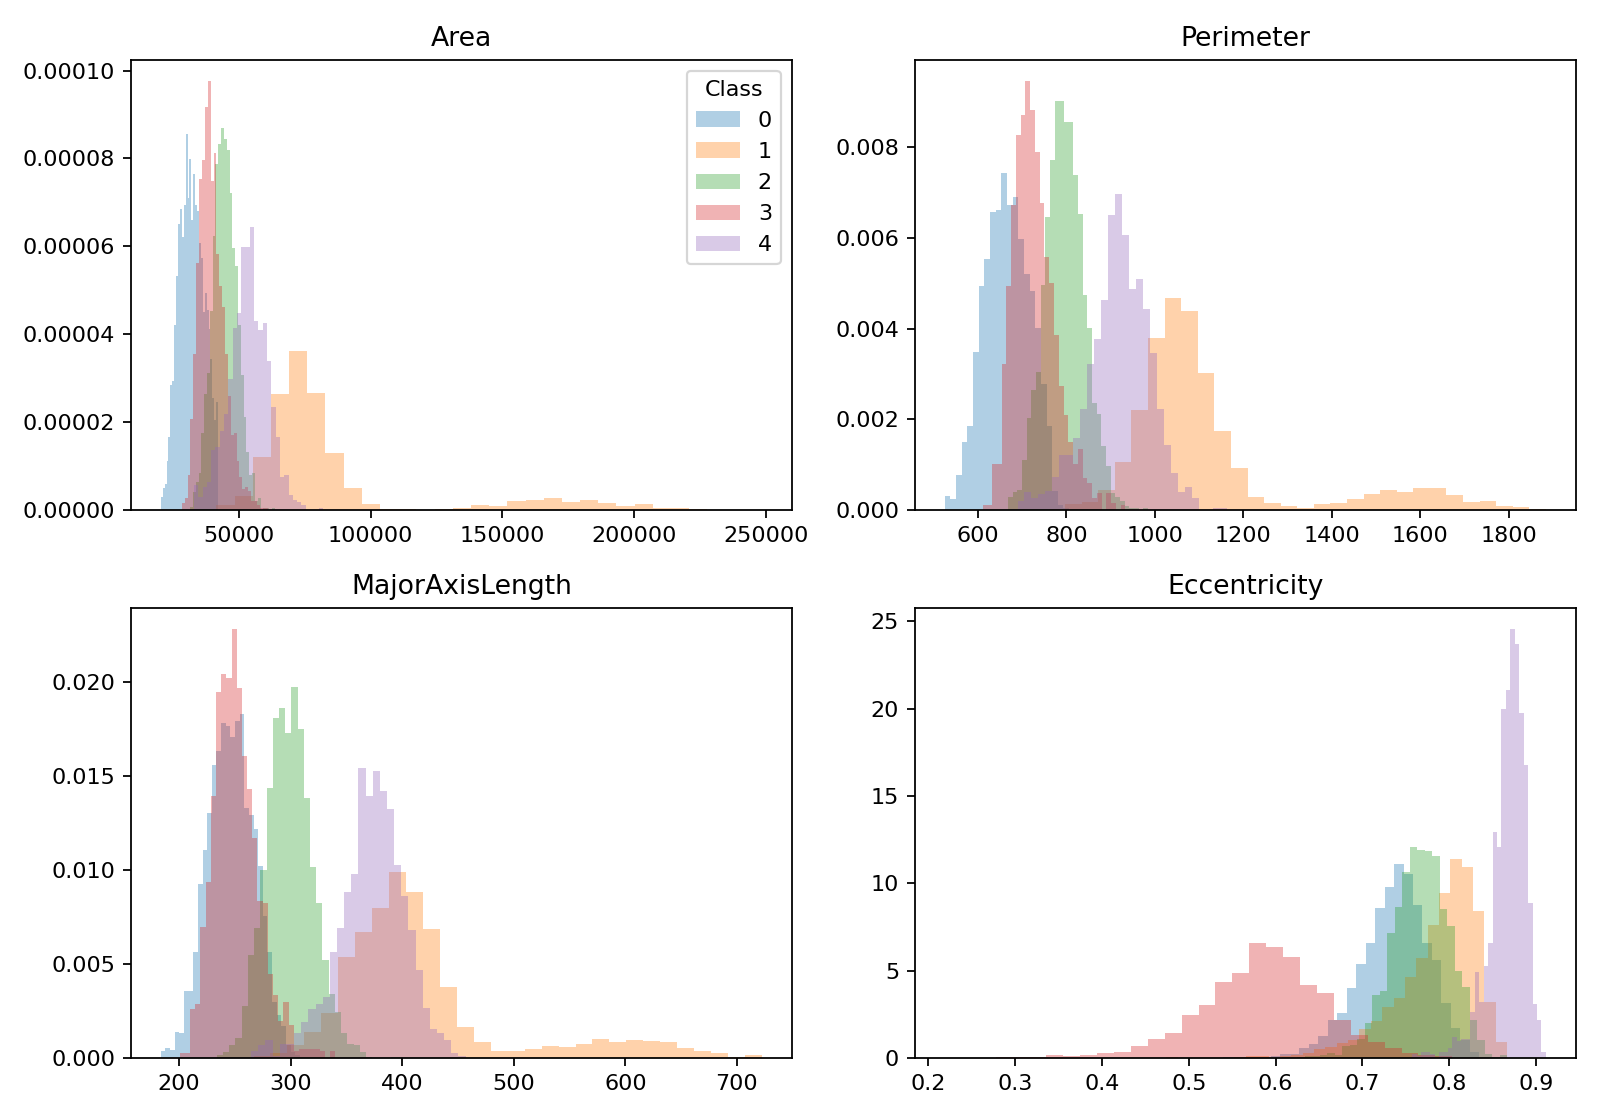

In [3]:
# Display the four-feature distribution figure generated from the real training data.
display(Image(filename=FIGURES / "feature_distributions.png"))


### 1.3 Continuous-feature correlation analysis


The size measurements are strongly related: Area and ConvexArea are almost perfectly correlated (1.000), and Perimeter and MajorAxisLength correlate 0.977. Eccentricity and Compactness correlate -0.970. I retain the original features because random forests tolerate correlated predictors, but standardise only for the gradient-based CVAE.


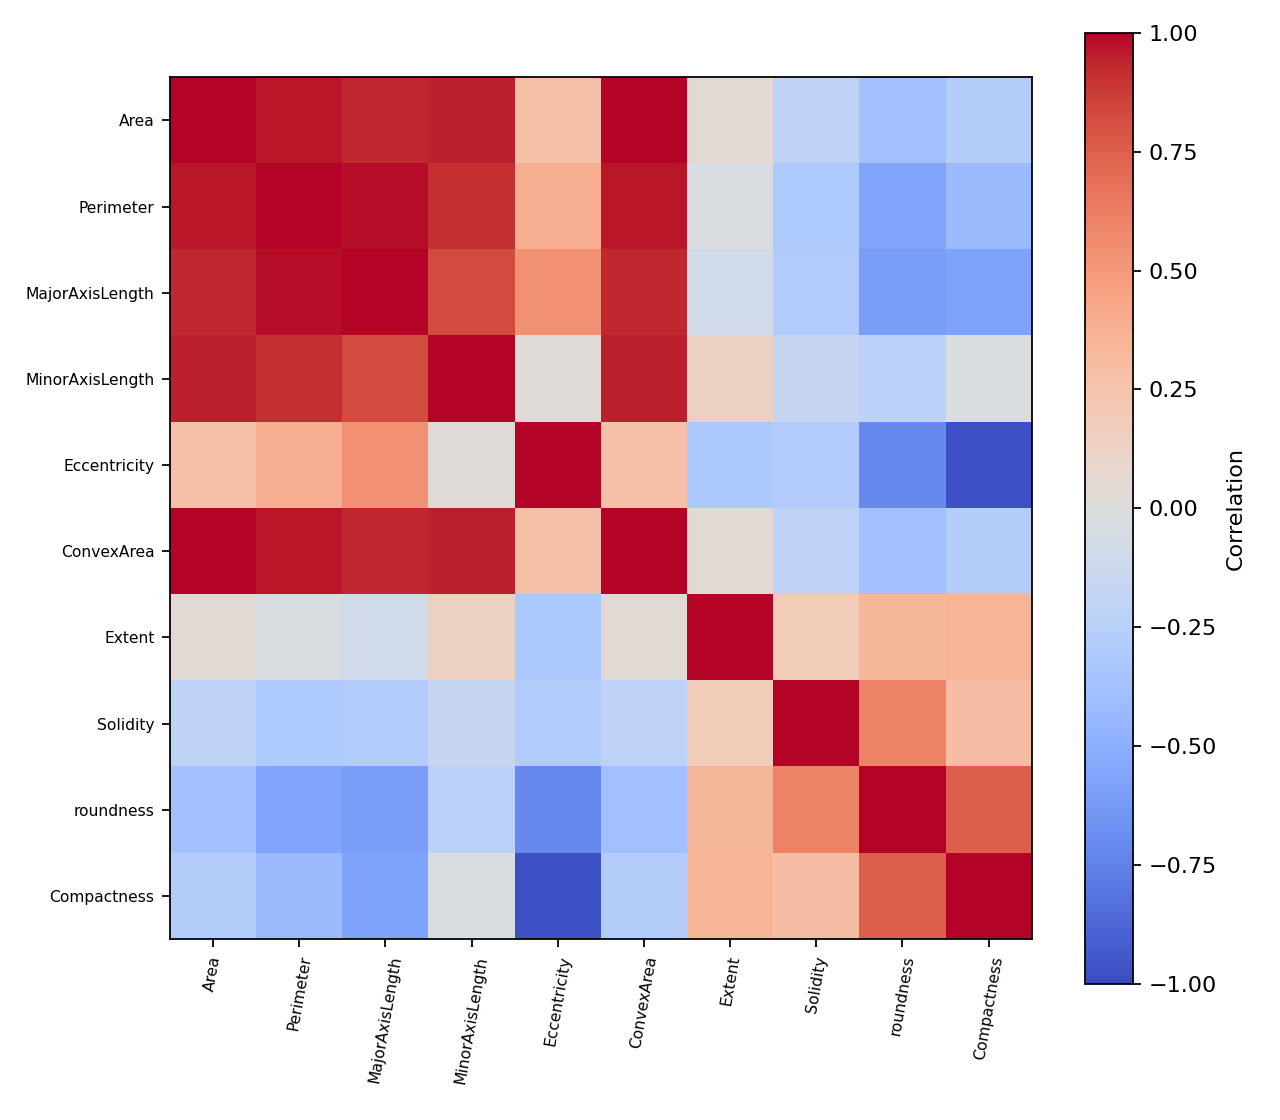

In [4]:
# Display the correlation heatmap calculated from the ten numerical features.
display(Image(filename=FIGURES / "real_correlation.png"))


### 1.4 EDA effects on preprocessing, model, metrics, and cross-validation


There are zero missing values, so imputation would add unsupported assumptions and is not used. Class 1 has much larger mean Area (86,472) than class 0 (32,165), while class 4 has the highest mean Eccentricity (0.87); the feature plots therefore support a non-linear classifier. Class imbalance makes macro-F1 the primary metric and accuracy the secondary metric. Stratified splitting and stratified five-fold CV preserve class proportions.


## Task 2 — Baseline classifier development


### 2.1 Necessary preprocessing and justification


The random-forest baseline uses the original numerical features because tree splits do not require scaling. Scaling is used only for the VAE, where gradient-based training benefits from comparable feature ranges.


### 2.2 Baseline classifier selection and justification


I use a class-weighted random forest. It can model non-linear feature relationships and its class weighting gives minority classes more influence during training.


### 2.3 Primary metric, secondary metric, and cross-validation strategy


Macro-F1 is primary because it weights every class equally. Accuracy is secondary. Five-fold stratified CV estimates development performance; a separate stratified 20% test set is used only for final evaluation.


### 2.4 Baseline training, evaluation, held-out test set, and leakage prevention


In [5]:
# Split once before model development so the held-out test data is never used in CV.
x_train, x_test, y_train, y_test = train_test_split(
    data[features], data[target], test_size=0.20, stratify=data[target], random_state=SEED
)

# Use five stratified folds to estimate baseline macro-F1 on training data only.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_model = a1.classifier()
cv_macro_f1 = cross_val_score(baseline_model, x_train, y_train, scoring="f1_macro", cv=cv, n_jobs=1)

# Fit the fixed baseline once on all training rows, then evaluate once on held-out test rows.
baseline_model.fit(x_train, y_train)
baseline_prediction = baseline_model.predict(x_test)
baseline_result = {
    "macro_f1": f1_score(y_test, baseline_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, baseline_prediction),
    "prediction": baseline_prediction,
}
print("CV macro-F1 mean:", cv_macro_f1.mean())
print("CV macro-F1 standard deviation:", cv_macro_f1.std())
print("Held-out macro-F1:", baseline_result["macro_f1"])
print("Held-out accuracy:", baseline_result["accuracy"])


CV macro-F1 mean: 0.9305563693481439
CV macro-F1 standard deviation: 0.002280578916501341
Held-out macro-F1: 0.9329380514698176
Held-out accuracy: 0.933140734626496


## Task 3 — Generative model development and justification


### 3.1 Selected generative model and justification


I use a conditional variational autoencoder (CVAE). It models continuous tabular features and conditions generation on the class label, allowing targeted minority-class augmentation.


### 3.2 Model architecture, components, and their roles


The CVAE uses a four-value class embedding, an encoder with 64 and 32 ReLU units, an eight-dimensional Gaussian latent space, and a decoder with 32 and 64 ReLU units. The encoder produces latent mean and log variance; the decoder reconstructs features from a latent sample and class embedding.


### 3.3 Tabular-data representation and generation


Each row is represented as ten scaled continuous features plus its class label. During generation, a random latent vector is concatenated with the requested class embedding and decoded back to a synthetic feature row.


### 3.4 Generative-model preprocessing or transformations


The VAE fits `StandardScaler` on the training features only. Synthetic samples are inverse-transformed before quality checks and classifier training.


### 3.5 Assumptions, limitations, and potential risks


A CVAE may smooth rare patterns, generate unrealistic feature combinations, or have limited diversity. Statistical similarity does not prove privacy or that the synthetic data contains no memorised rows.


## Task 4 — Data synthesis and quality assurance


### 4.1 Generative-model training procedure


In [6]:
# Train the conditional VAE on training data only; the function fits its scaler inside.
vae_model, vae_scaler = a1.train_vae(x_train, y_train, n_classes=data[target].nunique())
print("CVAE training completed with 100 epochs and batch size 256.")


CVAE training completed with 100 epochs and batch size 256.


### 4.2 Generation strategy and justification


The generator creates only enough minority-class samples to match the largest training class. This targets imbalance without unnecessarily multiplying the majority class.


### 4.3 Generate the synthetic dataset


In [7]:
# Sample labels for under-represented classes, generate rows, and save them for inspection.
synthetic_x, synthetic_y = a1.generate_balanced(vae_model, vae_scaler, x_train, y_train)
synthetic_data = synthetic_x.assign(Class=synthetic_y)
synthetic_data.to_csv(ROOT / "data" / "synthetic_train.csv", index=False)
print("Synthetic rows generated:", len(synthetic_data))
display(synthetic_data.head())


Synthetic rows generated: 3297


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Solidity,roundness,Compactness,Class
0,72578.421875,1048.192871,413.304749,223.240692,0.841354,72948.492188,0.726617,0.990591,0.825747,0.731397,1
1,82024.890625,1104.909668,441.353943,239.244202,0.838661,83746.562500,0.805378,0.979648,0.842482,0.731166,1
2,83038.703125,1145.953613,427.525940,250.867981,0.811810,83739.562500,0.784844,0.987493,0.802393,0.763525,1
3,72341.406250,1074.046265,397.321442,232.922562,0.816812,73560.843750,0.660257,0.984355,0.788033,0.761672,1
4,60341.097656,994.151489,324.912231,236.845581,0.696636,61664.382812,0.749726,0.975197,0.773107,0.846227,1


### 4.4 Visual and statistical comparison of real and synthetic data


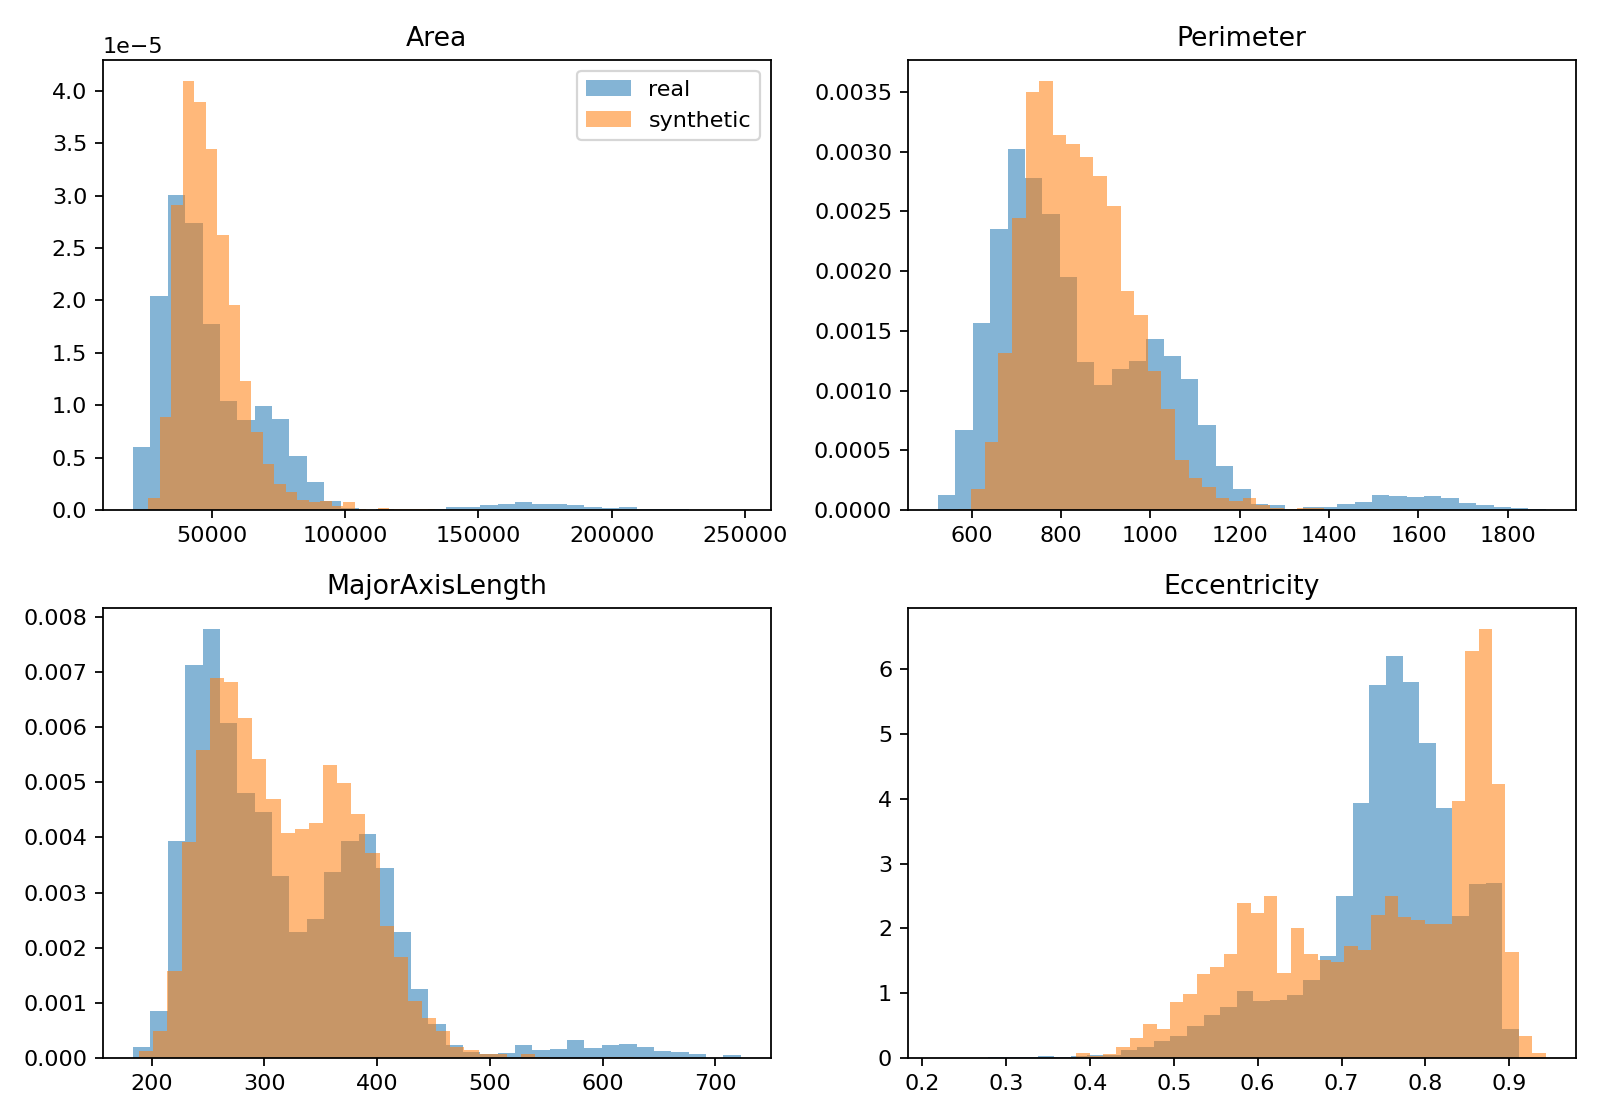

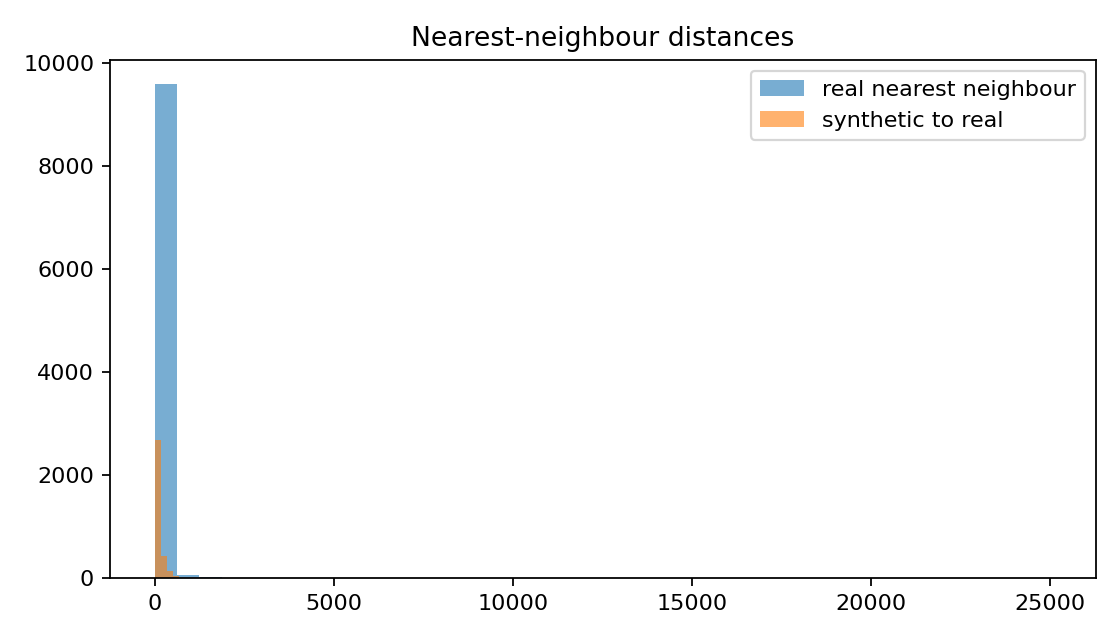

Mean absolute correlation gap: 0.18665910595217594
Median real nearest-neighbour distance: 35.50474291478542
Median synthetic-to-real nearest-neighbour distance: 77.75066228610389


In [8]:
# Compare overall and class-conditional distributions, correlations, and scaled nearest-neighbour distances.
correlation_gap, real_neighbour_distance, synthetic_neighbour_distance, quality_by_class = a1.save_quality_figures(
    x_train, y_train, synthetic_x, synthetic_y, features
)
display(Image(filename=FIGURES / "real_vs_synthetic.png"))
display(Image(filename=FIGURES / "nearest_neighbour_distances.png"))
display(Image(filename=FIGURES / "class_conditional_quality.png"))
display(quality_by_class)
print("Mean absolute correlation gap:", correlation_gap)
print("Median real nearest-neighbour distance:", real_neighbour_distance)
print("Median synthetic-to-real nearest-neighbour distance:", synthetic_neighbour_distance)


### 4.5 Critical evaluation of synthetic-data quality


The quality table is evaluated only within classes 1–4, which are the classes actually augmented; comparing their rows to all real classes would confound class differences with generation quality. In the Kaggle run, the mean class-conditional standardised mean gap was 0.185 and the mean correlation gap was 0.070; 98.2% of synthetic feature values remained inside their class-specific real-data ranges. Class 3 had the largest mean gap (0.365), so its samples deserve the most caution. Scaled synthetic-to-real median nearest-neighbour distance (0.328) exceeded the real-row value (0.264), which is consistent with non-duplicate samples but does not establish privacy.


## Task 5 — Classification and performance analysis with synthetic data


### 5.1 Train the augmented classifier with the Task 2 model, preprocessing, and hyperparameters


In [9]:
# Reuse exactly the same random-forest constructor and settings from Task 2.
augmented_model = a1.classifier()
x_augmented = pd.concat([x_train, synthetic_x], ignore_index=True)
y_augmented = pd.concat([y_train, synthetic_y], ignore_index=True)
augmented_model.fit(x_augmented, y_augmented)
augmented_prediction = augmented_model.predict(x_test)
augmented_result = {
    "macro_f1": f1_score(y_test, augmented_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, augmented_prediction),
    "prediction": augmented_prediction,
}
print("Augmented held-out macro-F1:", augmented_result["macro_f1"])
print("Augmented held-out accuracy:", augmented_result["accuracy"])


Augmented held-out macro-F1: 0.9257493779607714
Augmented held-out accuracy: 0.9261246388774247


### 5.2 Compare baseline and augmented classifiers on the same held-out test set


In [10]:
# Put both held-out results in one compact table and save the comparison figure.
comparison = pd.DataFrame([
    {"model": "Baseline random forest", **{key: value for key, value in baseline_result.items() if key != "prediction"}},
    {"model": "Augmented random forest", **{key: value for key, value in augmented_result.items() if key != "prediction"}},
])
display(comparison)
comparison.to_csv(ROOT / "data" / "performance.csv", index=False)
ax = comparison.set_index("model")[["macro_f1", "accuracy"]].plot.bar(ylim=(0, 1), rot=0)
ax.set_ylabel("score")
ax.set_title("Held-out classifier performance")
plt.tight_layout()
plt.savefig(FIGURES / "performance_comparison.png", dpi=160)
plt.show()


,model,macro_f1,accuracy
0,Baseline random forest,0.932938,0.933141
1,Augmented random forest,0.925749,0.926125


/var/folders/4_/w6brzrk54fx_7zxxpq16pj440000gn/T/ipykernel_17694/119998290.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 5.3 Class-level analysis


In [11]:
# Report precision, recall, and F1 for every class on the same held-out test set.
print("Baseline classification report")
print(classification_report(y_test, baseline_result["prediction"], zero_division=0))
print("Augmented classification report")
print(classification_report(y_test, augmented_result["prediction"], zero_division=0))
a1.save_confusion_matrices(y_test, baseline_result["prediction"], augmented_result["prediction"])
display(Image(filename=FIGURES / "confusion_matrices.png"))


Baseline classification report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       649
           1       0.99      0.97      0.98       635
           2       0.88      0.85      0.86       467
           3       0.94      0.96      0.95       346
           4       0.95      0.95      0.95       326

    accuracy                           0.93      2423
   macro avg       0.93      0.93      0.93      2423
weighted avg       0.93      0.93      0.93      2423

Augmented classification report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       649
           1       0.99      0.96      0.97       635
           2       0.85      0.85      0.85       467
           3       0.91      0.96      0.93       346
           4       0.94      0.97      0.95       326

    accuracy                           0.93      2423
   macro avg       0.92      0.93      0.93      2423
weighted avg  

### 5.4 Critical discussion of the synthetic-data effect


In the Kaggle T4 x2 run, augmentation reduced macro-F1 from 0.9322 to 0.9263 (-0.0060) and accuracy from 0.9327 to 0.9265. The class reports show the main losses in class 2 (F1 0.86 to 0.85) and class 3 (0.95 to 0.94); class 4 stayed at 0.95. Thus balancing class counts alone did not add useful decision boundaries. The CVAE's imperfect class-conditional fidelity can inject overlap or smooth rare patterns, so the final hidden-test model is the real-data baseline rather than the augmented model.


## Task 6 — Hidden test


### 6.1 Run the selected final model on a new CSV and create Class predictions


In [12]:
# Select the model by held-out macro-F1, then refit it on all released real data.
selected_name = max(
    [("Baseline random forest", baseline_result), ("Augmented random forest", augmented_result)],
    key=lambda item: item[1]["macro_f1"],
)[0]
final_model = a1.classifier()
if selected_name == "Augmented random forest":
    final_model.fit(
        pd.concat([data[features], synthetic_x], ignore_index=True),
        pd.concat([data[target], synthetic_y], ignore_index=True),
    )
else:
    final_model.fit(data[features], data[target])

# Save the final estimator and ordered feature list for predict.py.
model_path = MODELS / "1173808_Assignment1_final.joblib"
joblib.dump({"model": final_model, "features": features, "selected": selected_name}, model_path)
assert model_path.exists() and model_path.stat().st_size > 0
print("Selected final model:", selected_name)
print("Saved model:", model_path)


Selected final model: Baseline random forest
Saved model: /Users/yangliu/Documents/aimaster/1173808-COMP662A1/models/1173808_Assignment1_final.joblib


Run from the repository root:

```text
python predict.py data/new_beans.csv data/predictions.csv
```

The input must contain the same ten feature columns. The output has one `Class` column.
